# Теория информации

## Модуль 5: Энтропия, кросс-энтропия, KL-дивергенция

В этом ноутбуке мы рассмотрим основные концепции теории информации и их применение в машинном обучении.

### Содержание:
1. Энтропия Шеннона
2. Условная энтропия
3. Взаимная информация
4. Кросс-энтропия
5. KL-дивергенция
6. Применения в ML

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import rel_entr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Энтропия Шеннона

**Энтропия** измеряет количество информации или неопределённости в случайной величине.

### Для дискретной случайной величины:
$$H(X) = -\sum_{x} p(x) \log_2 p(x)$$

### Свойства:
1. $H(X) \geq 0$ (неотрицательность)
2. $H(X) = 0$ тогда и только тогда, когда $X$ детерминирована
3. Энтропия максимальна для равномерного распределения
4. $H(X, Y) \leq H(X) + H(Y)$ (субаддитивность)

### Примеры:
- Монета: $H = 1$ бит (максимальная неопределённость)
- Нечестная монета (p=0.9): $H \approx 0.47$ бит
- Кубик: $H = \log_2 6 \approx 2.58$ бит

Энтропия монеты
Честная монета: H = 1.0000 бит
Нечестная монета (p=0.9): H = 0.4690 бит


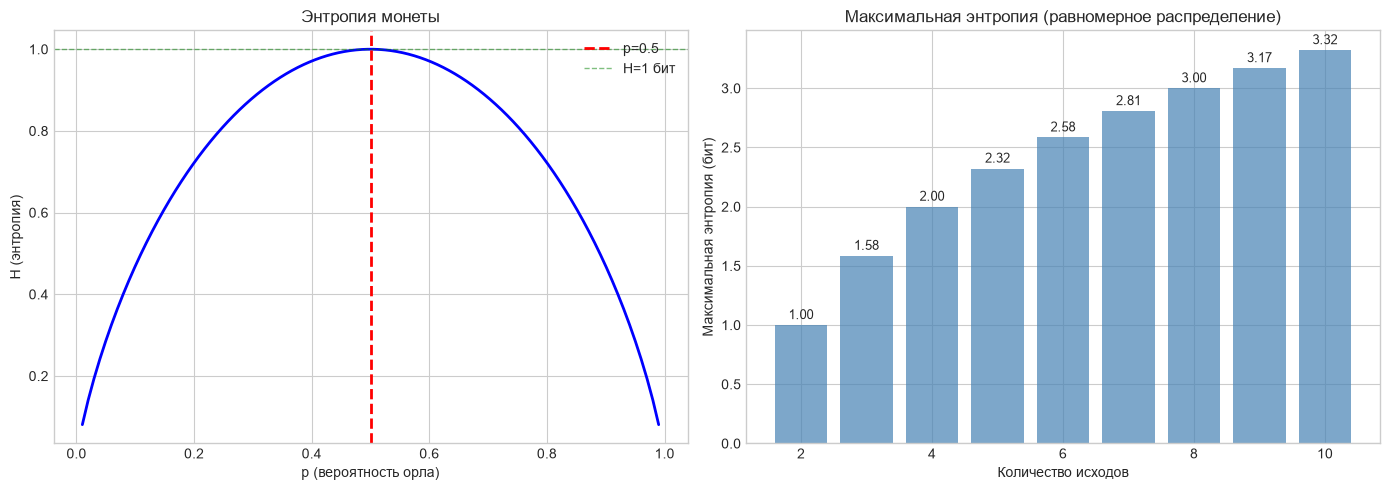

In [2]:
# Пример: Энтропия
def entropy(p):
    """Вычисление энтропии для дискретного распределения"""
    p = p[p > 0]  # Исключаем нули
    return -np.sum(p * np.log2(p))

# Монета
p_fair = np.array([0.5, 0.5])
p_biased = np.array([0.9, 0.1])

print('Энтропия монеты')
print('=' * 60)
print(f'Честная монета: H = {entropy(p_fair):.4f} бит')
print(f'Нечестная монета (p=0.9): H = {entropy(p_biased):.4f} бит')

# Зависимость энтропии от p для монеты
p_range = np.linspace(0.01, 0.99, 100)
entropies = [entropy(np.array([p, 1-p])) for p in p_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Энтропия монеты
axes[0].plot(p_range, entropies, 'b-', linewidth=2)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='p=0.5')
axes[0].axhline(1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='H=1 бит')
axes[0].set_xlabel('p (вероятность орла)')
axes[0].set_ylabel('H (энтропия)')
axes[0].set_title('Энтропия монеты')
axes[0].legend()

# Энтропия для разного числа исходов
n_outcomes = range(2, 11)
max_entropies = [np.log2(n) for n in n_outcomes]

axes[1].bar(n_outcomes, max_entropies, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Количество исходов')
axes[1].set_ylabel('Максимальная энтропия (бит)')
axes[1].set_title('Максимальная энтропия (равномерное распределение)')
for i, v in enumerate(max_entropies):
    axes[1].text(i+2, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Кросс-энтропия

**Кросс-энтропия** измеряет, насколько хорошо распределение $q$ аппроксимирует истинное распределение $p$.

$$H(p, q) = -\sum_{x} p(x) \log q(x)$$

### Свойства:
1. $H(p, q) \geq H(p)$ (всегда не меньше энтропии)
2. $H(p, q) = H(p)$ тогда и только тогда, когда $p = q$
3. Асимметрична: $H(p, q) \neq H(q, p)$ в общем случае

### Применение в ML:
**Функция потерь (loss function) для классификации:**
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i)]$$

где $y_i$ — истинная метка, $\hat{y}_i$ — предсказание модели.

Кросс-энтропия для разных предсказаний
Истинное распределение: [0.7 0.2 0.1]

Идеальное      : H(p,q) = 1.1568, H(p) = 1.1568, D_KL = 0.0000
Хорошее        : H(p,q) = 1.1955, H(p) = 1.1568, D_KL = 0.0387
Плохое         : H(p,q) = 2.7464, H(p) = 1.1568, D_KL = 1.5897
Случайное      : H(p,q) = 1.5850, H(p) = 1.1568, D_KL = 0.4282


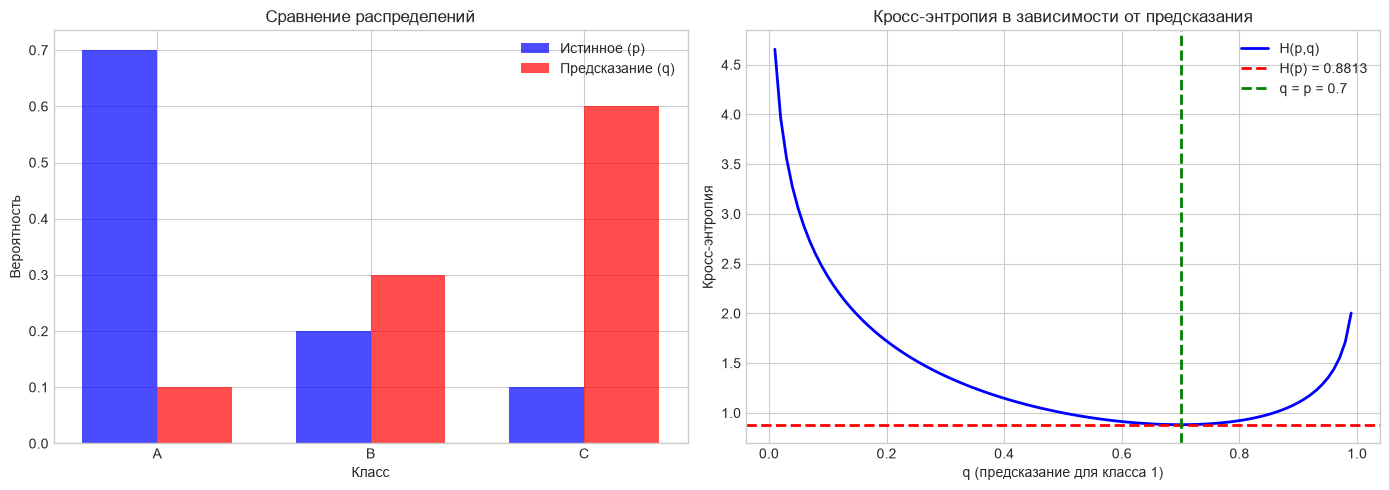

In [4]:
# Пример: Кросс-энтропия
def cross_entropy(p, q):
    """Вычисление кросс-энтропии"""
    # Добавляем epsilon для численной стабильности
    eps = 1e-10
    q = np.clip(q, eps, 1 - eps)
    return -np.sum(p * np.log2(q))

# Истинное распределение
p_true = np.array([0.7, 0.2, 0.1])  # Три класса

# Разные предсказания
predictions = {
    'Идеальное': np.array([0.7, 0.2, 0.1]),
    'Хорошее': np.array([0.6, 0.3, 0.1]),
    'Плохое': np.array([0.1, 0.3, 0.6]),
    'Случайное': np.array([1/3, 1/3, 1/3])
}

print('Кросс-энтропия для разных предсказаний')
print('=' * 60)
print(f'Истинное распределение: {p_true}')
print()

for name, q in predictions.items():
    h_true = entropy(p_true)
    h_cross = cross_entropy(p_true, q)
    print(f'{name:<15}: H(p,q) = {h_cross:.4f}, H(p) = {h_true:.4f}, D_KL = {h_cross - h_true:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределения
x = np.arange(3)
width = 0.35
axes[0].bar(x - width/2, p_true, width, label='Истинное (p)', color='blue', alpha=0.7)
axes[0].bar(x + width/2, predictions['Плохое'], width, label='Предсказание (q)', color='red', alpha=0.7)
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Вероятность')
axes[0].set_title('Сравнение распределений')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['A', 'B', 'C'])
axes[0].legend()

# Кросс-энтропия для разных q
q_values = np.linspace(0.01, 0.99, 100)
cross_entropies = [cross_entropy(np.array([0.7, 0.3]), np.array([q, 1-q])) for q in q_values]

axes[1].plot(q_values, cross_entropies, 'b-', linewidth=2, label='H(p,q)')
axes[1].axhline(entropy(np.array([0.7, 0.3])), color='red', linestyle='--', linewidth=2, 
                label=f'H(p) = {entropy(np.array([0.7, 0.3])):.4f}')
axes[1].axvline(0.7, color='green', linestyle='--', linewidth=2, label='q = p = 0.7')
axes[1].set_xlabel('q (предсказание для класса 1)')
axes[1].set_ylabel('Кросс-энтропия')
axes[1].set_title('Кросс-энтропия в зависимости от предсказания')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. KL-дивергенция (Дивергенция Кульбака-Лейблера)

**KL-дивергенция** измеряет разницу между двумя распределениями.

$$D_{KL}(p || q) = \sum_{x} p(x) \log \frac{p(x)}{q(x)} = H(p, q) - H(p)$$

### Свойства:
1. $D_{KL}(p || q) \geq 0$ (неотрицательность)
2. $D_{KL}(p || q) = 0$ тогда и только тогда, когда $p = q$
3. **Асимметрична:** $D_{KL}(p || q) \neq D_{KL}(q || p)$
4. Не является метрикой (не удовлетворяет неравенству треугольника)

### Применения:
- Вариационный автоэнкодер (VAE)
- Дистилляция знаний
- Обнаружение аномалий
- Сравнение распределений

KL-дивергенция для нормальных распределений
p = N(0,1)
q1 = N(2,1): D_KL(p||q1) = 2.0000
q2 = N(0,2): D_KL(p||q2) = 0.3181

Асимметрия:
D_KL(p||q1) = 2.0000
D_KL(q1||p) = 2.0000


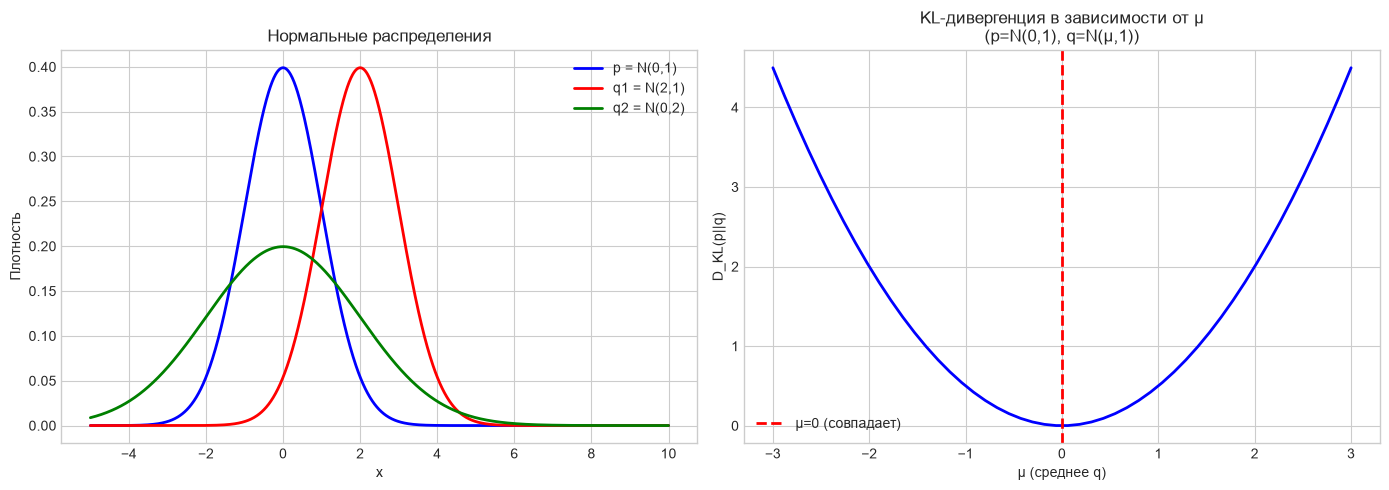

In [5]:
# Пример: KL-дивергенция
def kl_divergence(p, q):
    """Вычисление KL-дивергенции"""
    eps = 1e-10
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))

# Пример: Нормальные распределения
x = np.linspace(-5, 10, 1000)

# p = N(0, 1), q = N(2, 1)
p = stats.norm.pdf(x, 0, 1)
q1 = stats.norm.pdf(x, 2, 1)
q2 = stats.norm.pdf(x, 0, 2)

# KL-дивергенция (для непрерывных: интеграл)
def kl_continuous(p_params, q_params, x):
    p = stats.norm.pdf(x, *p_params)
    q = stats.norm.pdf(x, *q_params)
    # Избегаем деления на ноль
    mask = (p > 1e-10) & (q > 1e-10)
    return np.trapz(p[mask] * np.log(p[mask] / q[mask]), x[mask])

kl1 = kl_continuous((0, 1), (2, 1), x)
kl2 = kl_continuous((0, 1), (0, 2), x)

print('KL-дивергенция для нормальных распределений')
print('=' * 60)
print(f'p = N(0,1)')
print(f'q1 = N(2,1): D_KL(p||q1) = {kl1:.4f}')
print(f'q2 = N(0,2): D_KL(p||q2) = {kl2:.4f}')

# Асимметрия
kl_reverse = kl_continuous((2, 1), (0, 1), x)
print(f'\nАсимметрия:')
print(f'D_KL(p||q1) = {kl1:.4f}')
print(f'D_KL(q1||p) = {kl_reverse:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределения
axes[0].plot(x, p, 'b-', linewidth=2, label='p = N(0,1)')
axes[0].plot(x, q1, 'r-', linewidth=2, label='q1 = N(2,1)')
axes[0].plot(x, q2, 'g-', linewidth=2, label='q2 = N(0,2)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Нормальные распределения')
axes[0].legend()

# KL-дивергенция для разных параметров
mu_values = np.linspace(-3, 3, 50)
kl_values = [kl_continuous((0, 1), (mu, 1), x) for mu in mu_values]

axes[1].plot(mu_values, kl_values, 'b-', linewidth=2)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='μ=0 (совпадает)')
axes[1].set_xlabel('μ (среднее q)')
axes[1].set_ylabel('D_KL(p||q)')
axes[1].set_title('KL-дивергенция в зависимости от μ\n(p=N(0,1), q=N(μ,1))')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Применения в машинном обучении

### 4.1 Функция потерь для классификации

**Binary Cross-Entropy (BCE):**
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i)]$$

**Categorical Cross-Entropy:**
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log \hat{y}_{ic}$$

### 4.2 Вариационный автоэнкодер (VAE)
$$\mathcal{L}_{VAE} = E_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) || p(z))$$

### 4.3 Дистилляция знаний
Используем KL-дивергенцию для передачи знаний от большой модели к маленькой.

Binary Cross-Entropy для разных моделей
Хорошая модель: BCE = 0.0476
Плохая модель: BCE = 1.0463

Идеальная модель: BCE = 0.0000


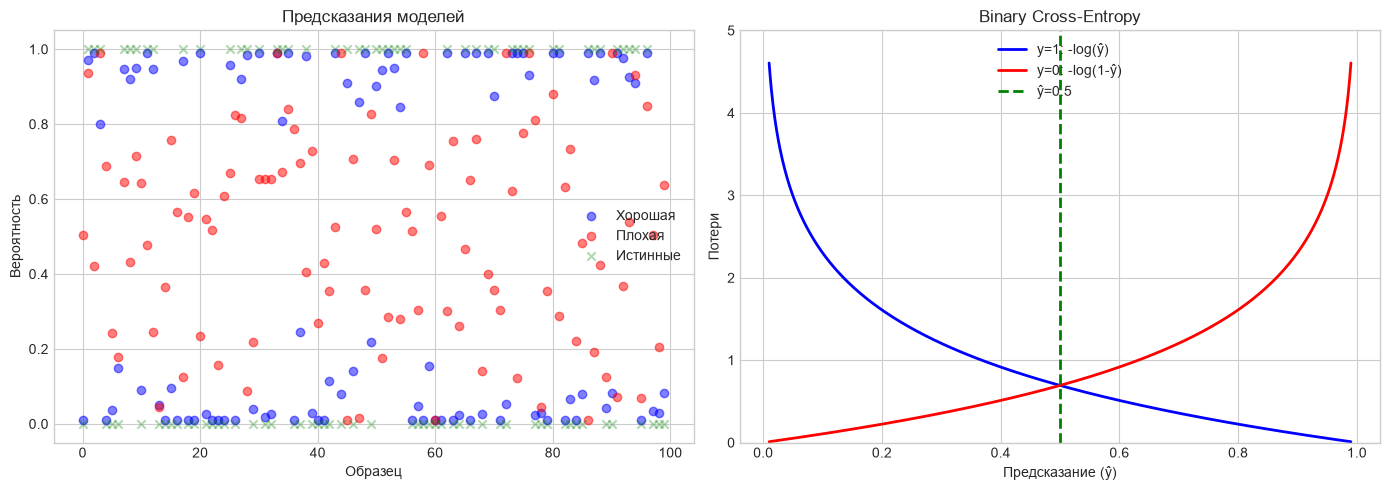

In [6]:
# Пример: Binary Cross-Entropy в действии
np.random.seed(42)

# Симуляция бинарной классификации
n_samples = 100

# Истинные метки
y_true = np.random.binomial(1, 0.5, n_samples)

# Предсказания модели (вероятности)
y_pred_good = np.clip(y_true + np.random.normal(0, 0.1, n_samples), 0.01, 0.99)
y_pred_bad = np.clip(0.5 + np.random.normal(0, 0.3, n_samples), 0.01, 0.99)

# Binary Cross-Entropy
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-10
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

bce_good = binary_cross_entropy(y_true, y_pred_good)
bce_bad = binary_cross_entropy(y_true, y_pred_bad)

print('Binary Cross-Entropy для разных моделей')
print('=' * 60)
print(f'Хорошая модель: BCE = {bce_good:.4f}')
print(f'Плохая модель: BCE = {bce_bad:.4f}')
print(f'\nИдеальная модель: BCE = {binary_cross_entropy(y_true, y_true):.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Предсказания
axes[0].scatter(range(n_samples), y_pred_good, alpha=0.5, color='blue', label='Хорошая')
axes[0].scatter(range(n_samples), y_pred_bad, alpha=0.5, color='red', label='Плохая')
axes[0].scatter(range(n_samples), y_true, alpha=0.3, color='green', marker='x', label='Истинные')
axes[0].set_xlabel('Образец')
axes[0].set_ylabel('Вероятность')
axes[0].set_title('Предсказания моделей')
axes[0].legend()

# BCE в зависимости от предсказания
y_pred_range = np.linspace(0.01, 0.99, 1000)

# Для y=1
bce_y1 = -np.log(y_pred_range)
# Для y=0
bce_y0 = -np.log(1 - y_pred_range)

axes[1].plot(y_pred_range, bce_y1, 'b-', linewidth=2, label='y=1: -log(ŷ)')
axes[1].plot(y_pred_range, bce_y0, 'r-', linewidth=2, label='y=0: -log(1-ŷ)')
axes[1].axvline(0.5, color='green', linestyle='--', linewidth=2, label='ŷ=0.5')
axes[1].set_xlabel('Предсказание (ŷ)')
axes[1].set_ylabel('Потери')
axes[1].set_title('Binary Cross-Entropy')
axes[1].legend()
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Энтропия
Вычислите энтропию для:
1. Кубика (6 равновероятных исходов)
2. Монеты с p(H) = 0.8
3. Распределения: P = {A: 0.5, B: 0.25, C: 0.125, D: 0.125}

### Упражнение 2: Кросс-энтропия
Даны распределения:
- p = (0.7, 0.3)
- q1 = (0.6, 0.4)
- q2 = (0.9, 0.1)

1. Вычислите H(p, q1) и H(p, q2)
2. Какое распределение лучше аппроксимирует p?

### Упражнение 3: KL-дивергенция
1. Вычислите D_KL(p || q1) и D_KL(p || q2) из упражнения 2
2. Проверьте, что KL-дивергенция неотрицательна
3. Проверьте асимметрию: D_KL(p || q1) vs D_KL(q1 || p)

### Упражнение 4: Применение в ML
Рассмотрите задачу классификации с тремя классами:
- Истинное: y = (1, 0, 0) (класс A)
- Предсказание 1: ŷ = (0.8, 0.1, 0.1)
- Предсказание 2: ŷ = (0.1, 0.8, 0.1)

1. Вычислите categorical cross-entropy для каждого предсказания
2. Какое предсказание лучше?

---

**Решения** можно найти в ноутбуке `solutions/12_Solutions.ipynb`